<a href="https://colab.research.google.com/github/Charly1368/Modulo-2---Modelos-Estad-sticos/blob/Proyecto_ModuloII/Pr%C3%A1ctica_2_Datos_en_Crudo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

</center>

  <h1><strong>Universidad Nacional Autónoma de México</strong></h1>
  <h2>Facultad de Estudios Superiores Acatlán</h2>
  <h3>Diplomado en Técnicas Estadísticas y Minería de Datos</h3>

  <h3>Módulo: Minería de Datos</h3>
  <h3>Práctica 2 - Datos en Crudo</h3>

  

  <h4>Grupo 35</h4>

  <h2>Alumno: <strong>Bustillos Araiza Carlos<strong><h1>
    
</center>


<hr style="width:60%; border: 1px solid #888;">


# Modelo de Análisis y Pronóstico basado en la variable 'G'
Primero revise el archivo de datos.csv y me base a realizar un análisis predictivo tomando como dependencia la variable `G`.

## ¿Por qué? Para darle más sentido al análisis

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

# Cargar archivo
df = pd.read_csv('/content/Datos.csv')
df = df.dropna()

# Codificar variable objetivo
label_encoder = LabelEncoder()
df['G_encoded'] = label_encoder.fit_transform(df['G'])

# Filtrar clases con al menos 10 registros
class_counts = df['G_encoded'].value_counts()
valid_classes = class_counts[class_counts >= 10].index
df = df[df['G_encoded'].isin(valid_classes)]

# Variables predictoras y objetivo
X = df.drop(columns=['G', 'G_encoded', 'F'], errors='ignore').select_dtypes(include='number')
y = df['G_encoded']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [60]:
# Entrenar el modelo
model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Reporte
target_names = label_encoder.inverse_transform(sorted(y.unique()))
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

         (nu       0.00      0.00      0.00       111
          AE       0.00      0.00      0.00        30
          AL       0.00      0.00      0.00         4
          AP       0.00      0.00      0.00         6
          AR       0.00      0.00      0.00        12
          AT       0.00      0.00      0.00         6
          AU       0.00      0.00      0.00       292
          BA       0.00      0.00      0.00         3
          BD       0.00      0.00      0.00        13
          BE       0.00      0.00      0.00        26
          BG       0.00      0.00      0.00        12
          BR       0.05      0.04      0.04        53
          BZ       0.00      0.00      0.00         5
          CA       0.00      0.00      0.00       277
          CH       0.00      0.00      0.00        12
          CL       0.00      0.00      0.00         5
          CN       0.00      0.00      0.00        12
          CO       0.00    

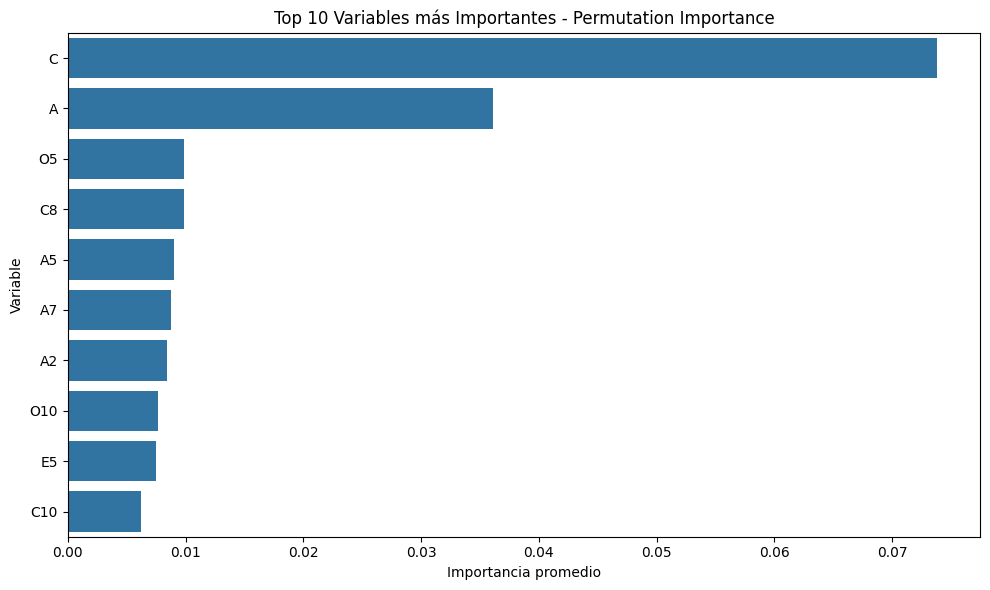

In [61]:
# Permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances = result.importances_mean

importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False).head(10)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importance_df)
plt.title('Top 10 Variables más Importantes - Permutation Importance')
plt.xlabel('Importancia promedio')
plt.tight_layout()
plt.show()

## Conclusión
Este modelo permite predecir la nacionalidad `G` usando variables cuantitativas. La importancia de las variables se calculó mediante `permutation_importance` para asegurar interpretabilidad y robustez del modelo.

# 1. Analizar los datos y obtener las estadísticas descriptivas (al menos 4 medidas)

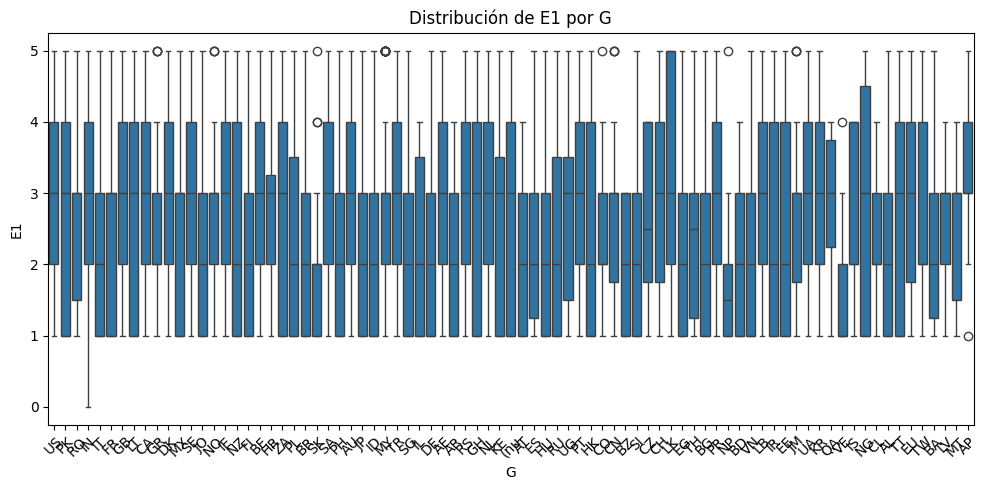

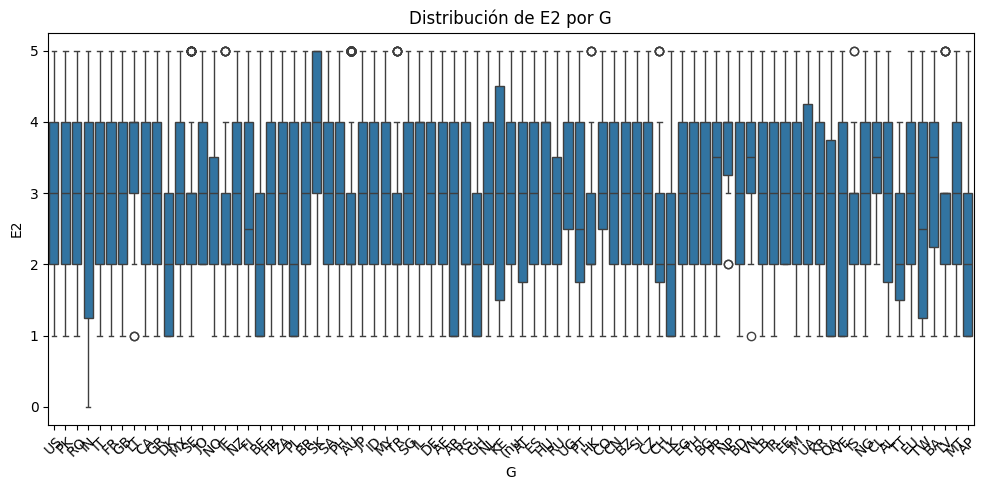

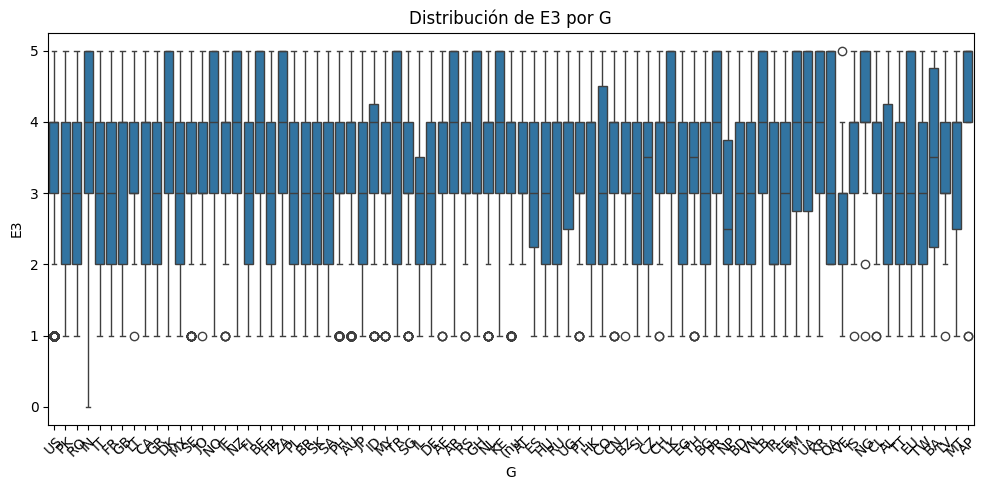

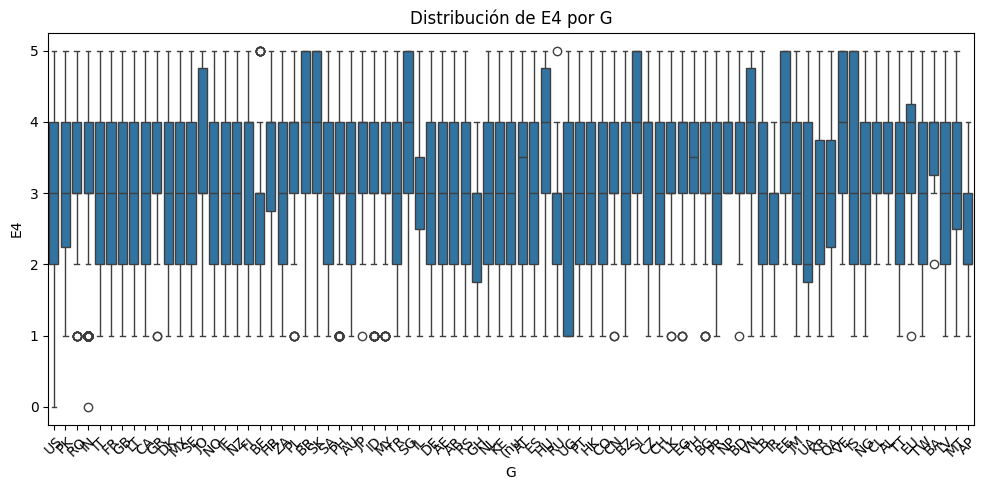

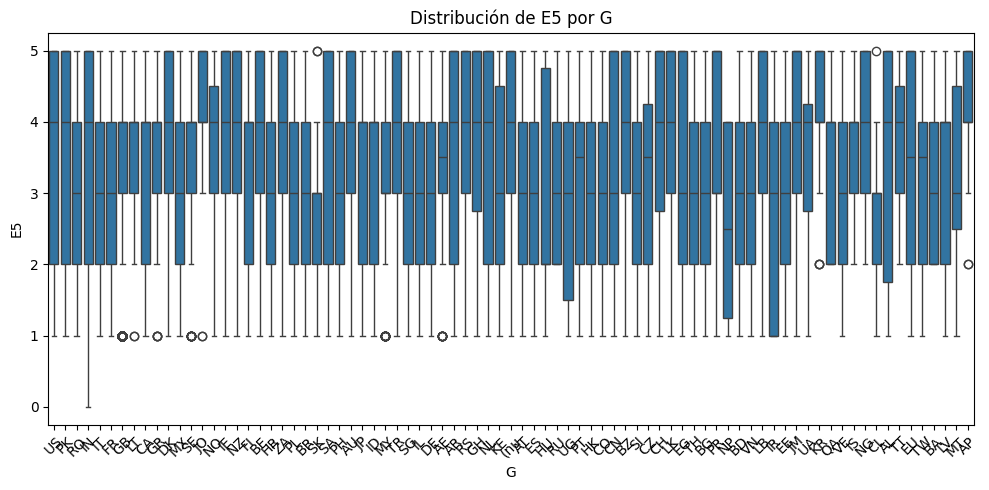

E1                                                  E2          \
        Media Mediana Desviación Estándar Mínimo Máximo     Media Mediana   
G                                                                           
(nu  2.555556     3.0            1.278067      1      5  2.813008     3.0   
AE   2.860000     3.0            1.263473      1      5  2.920000     3.0   
AL   2.166667     2.0            1.337116      1      5  2.750000     3.0   
AP   3.421053     3.0            1.169795      1      5  2.368421     2.0   
AR   2.341463     2.0            1.015129      1      4  2.707317     3.0   

                                       ...        E4          \
    Desviación Estándar Mínimo Máximo  ...     Media Mediana   
G                                      ...                     
(nu            1.363437      1      5  ...  3.243902     3.0   
AE             1.307940      1      5  ...  3.060000     3.0   
AL             1.356801      1      5  ...  3.416667     3.0   
AP             1.382852      1      5  ...  2.473684     2.0   
AR             1.453339      1      5  ...  3.073171     3.0   

                                             E5                              \
    Desviación Estándar Mínimo Máximo     Media Mediana Desviación Estándar   
G                                                                             
(nu            1.222578      1      5  3.471545     4.0            1.263999   
AE             1.187647      1      5  3.410000     3.5            1.181465   
AL             0.792961      2      5  3.416667     4.0            1.781640   
AP             1.073334      1      4  4.052632     4.0            0.970320   
AR             1.311302      1      5  3.439024     4.0            1.566027   

                   
    Mínimo Máximo  
G                  
(nu      1      5  
AE       1      5  
AL       1      5  
AP       2      5  
AR       1      5  

[5 rows x 25 columns]

In [62]:
# Filtrar solo columnas numéricas antes de calcular estadísticas
numeric_cols = df.select_dtypes(include=["number"])
descriptive_stats = numeric_cols.describe().T

# Calcular estadísticas descriptivas personalizadas por grupo (sin usar .describe)
grouped = df.groupby("G")
custom_stats = grouped.agg([
    ("Media", "mean"),
    ("Mediana", "median"),
    ("Desviación Estándar", "std"),
    ("Mínimo", "min"),
    ("Máximo", "max")
])

# Limitar a columnas numéricas para simplificar los gráficos
numeric_cols = df.select_dtypes(include='number').columns
selected_cols = numeric_cols[:5]  # Tomar las primeras 5 columnas numéricas para ejemplo

# Crear boxplots comparativos por grupo de G para estas variables
import matplotlib.pyplot as plt
import seaborn as sns

# Gráficos por cada variable numérica seleccionada
for col in selected_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='G', y=col, data=df)
    plt.title(f'Distribución de {col} por G')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Filtrar solo las estadísticas de las columnas seleccionadas
filtered_stats = custom_stats[selected_cols]

# Mostrar estadísticas
filtered_stats.head()

# Estadísticas Descriptivas Agrupadas por la Variable Dependiente "G" (País)

Se calcularon cinco medidas por variable numérica:

- **Media**
- **Mediana**
- **Desviación estándar**
- **Mínimo**
- **Máximo**

Estas se muestran separadas por país o categoría de **G** (como AE, A1, A2, etc.), lo que nos permite observar claramente las diferencias entre los grupos.

## Gráficos Comparativos Tipo Boxplot

También se generaron gráficos comparativos tipo **boxplot** para las primeras cinco variables numéricas. Estos gráficos permiten visualizar:

- **La dispersión** de cada variable por país.
- **Los valores atípicos**.
- **El rango intercuartílico**.
- **La asimetría de la distribución**.

Este análisis proporciona una comprensión clara de las diferencias en los datos a nivel grupal.

# 2. Seleccionar y justificar las 4 variables más representativas


# Análisis Dependiente de la Variable 'G'
Este análisis se centra en la variable dependiente `G`, con estadísticas descriptivas, visualización de datos y selección de las variables más representativas.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('/content/Datos.csv')
df = df.dropna()

## Estadísticas Descriptivas por 'G'
Se calculan estadísticas como media, mediana, desviación estándar, mínimo y máximo para cada grupo de la variable `G`.

In [64]:
grouped = df.groupby("G")
custom_stats = grouped.agg([
    ("Media", "mean"),
    ("Mediana", "median"),
    ("Desviación Estándar", "std"),
    ("Mínimo", "min"),
    ("Máximo", "max")
])
custom_stats

E1                                                  E2          \
        Media Mediana Desviación Estándar Mínimo Máximo     Media Mediana   
G                                                                           
(nu  2.555556     3.0            1.278067      1      5  2.813008     3.0   
A1   2.750000     3.0            1.164965      1      4  2.750000     2.5   
A2   1.888889     2.0            0.927961      1      3  3.444444     4.0   
AE   2.860000     3.0            1.263473      1      5  2.920000     3.0   
AG   3.000000     3.0                 NaN      3      3  5.000000     5.0   
..        ...     ...                 ...    ...    ...       ...     ...   
VI   1.500000     1.5            0.707107      1      2  2.500000     2.5   
VN   2.100000     2.0            1.093870      1      5  3.400000     3.5   
ZA   2.601124     3.0            1.263749      1      5  2.747191     3.0   
ZM   3.000000     3.0            0.000000      3      3  4.500000     4.5   
ZW   1.666667     2.0            0.577350      1      2  2.666667     3.0   

                                       ...         E          \
    Desviación Estándar Mínimo Máximo  ...     Media Mediana   
G                                      ...                     
(nu            1.363437      1      5  ...  1.135501     1.0   
A1             1.281740      1      5  ...  1.000000     1.0   
A2             1.333333      1      5  ...  1.000000     1.0   
AE             1.307940      1      5  ...  1.050000     1.0   
AG                  NaN      5      5  ...  1.000000     1.0   
..                  ...    ...    ...  ...       ...     ...   
VI             0.707107      2      3  ...  1.000000     1.0   
VN             1.101723      1      5  ...  1.133333     1.0   
ZA             1.326870      1      5  ...  1.117978     1.0   
ZM             0.707107      4      5  ...  1.000000     1.0   
ZW             1.527525      1      4  ...  1.000000     1.0   

                                              F                              \
    Desviación Estándar Mínimo Máximo     Media Mediana Desviación Estándar   
G                                                                             
(nu            0.452123      0      3  2.116531     1.0            1.587989   
A1             0.000000      1      1  1.625000     1.0            1.407886   
A2             0.000000      1      1  2.000000     1.0            1.732051   
AE             0.261116      0      2  1.910000     1.0            1.583341   
AG                  NaN      1      1  2.000000     2.0                 NaN   
..                  ...    ...    ...       ...     ...                 ...   
VI             0.000000      1      1  1.000000     1.0            0.000000   
VN             0.507416      1      3  1.966667     1.0            1.496740   
ZA             0.356715      0      3  1.533708     1.0            1.184404   
ZM             0.000000      1      1  1.000000     1.0            0.000000   
ZW             0.000000      1      1  1.333333     1.0            0.577350   

                   
    Mínimo Máximo  
G                  
(nu      1      5  
A1       1      5  
A2       1      5  
AE       1      5  
AG       2      2  
..     ...    ...  
VI       1      1  
VN       1      5  
ZA       1      5  
ZM       1      1  
ZW       1      2  

[161 rows x 280 columns]

## Visualización por Boxplots
Se presentan boxplots comparativos de las primeras 5 variables numéricas agrupadas por `G`.

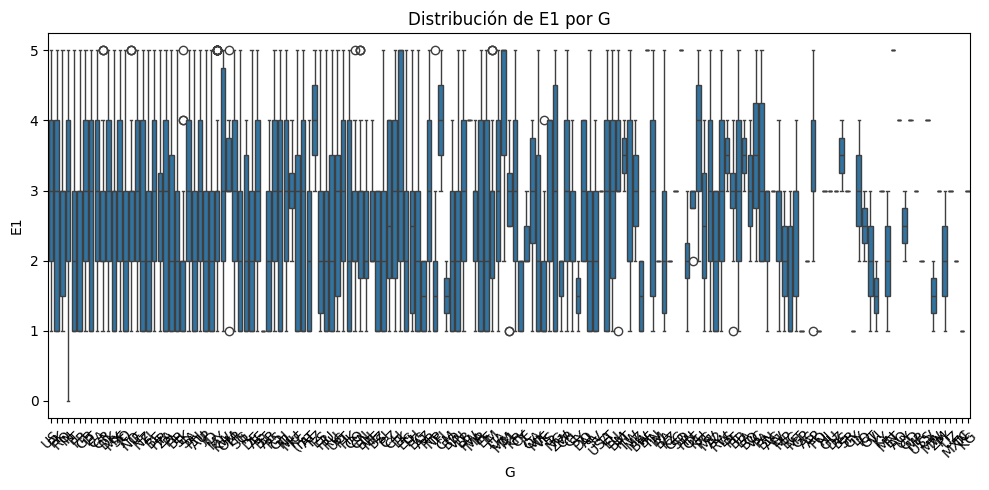

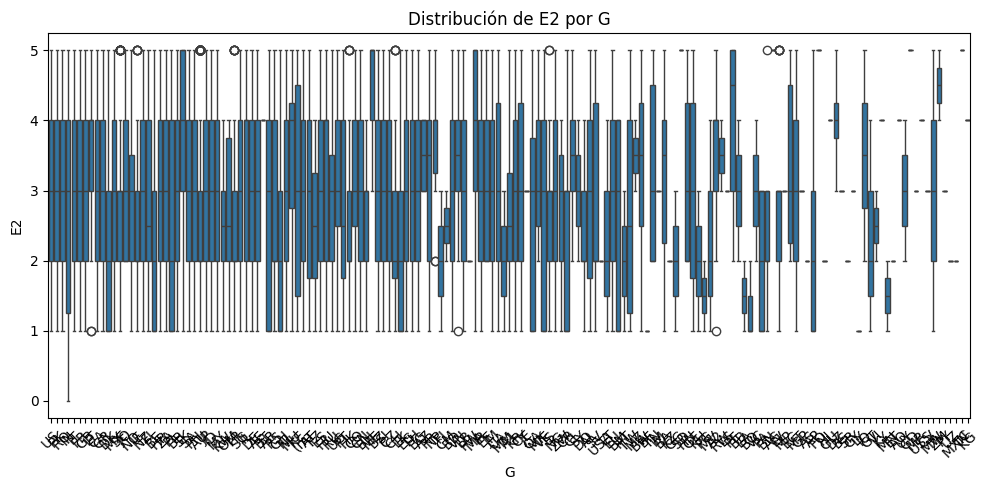

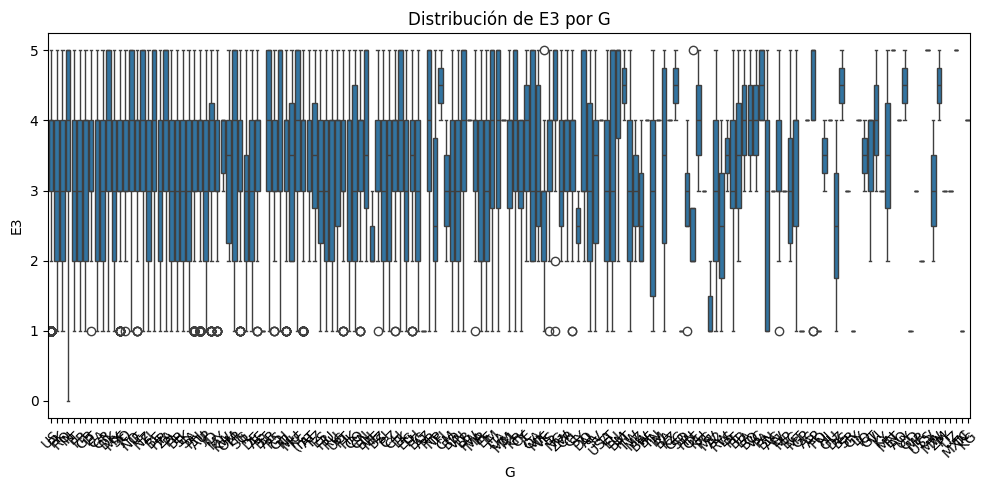

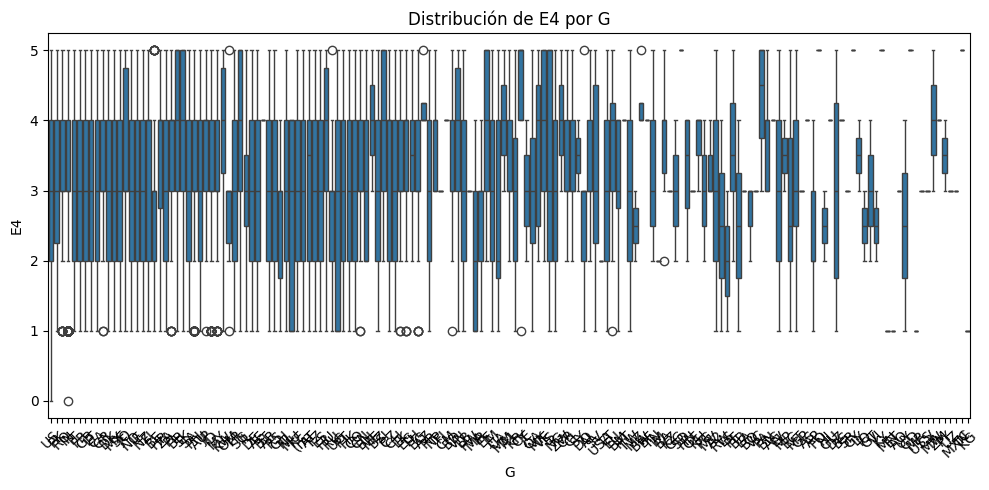

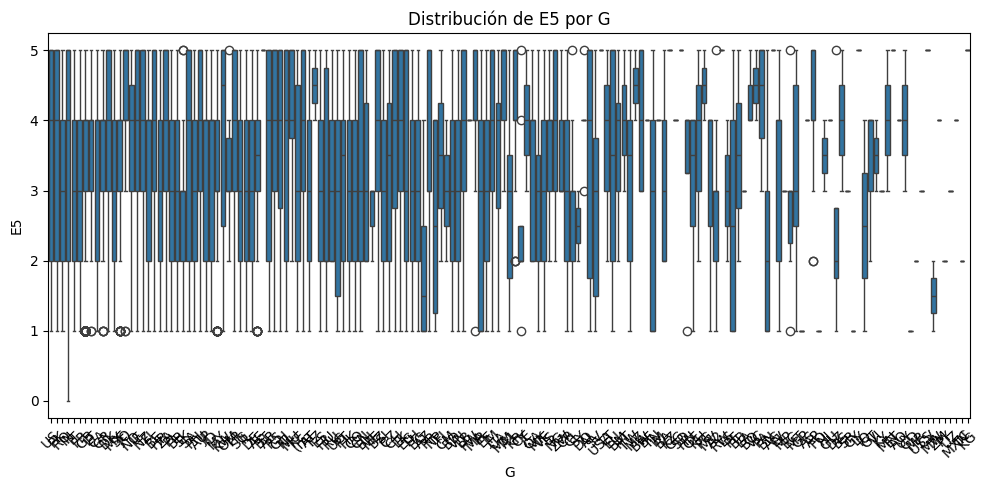

In [65]:
numeric_cols = df.select_dtypes(include='number').columns
selected_cols = numeric_cols[:5]

for col in selected_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='G', y=col, data=df)
    plt.title(f'Distribución de {col} por G')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Selección y Justificación de Variables Representativas

Con base en el análisis estadístico y visual realizado (boxplots y estadísticas descriptivas agrupadas por `G`), se seleccionan las siguientes **4 variables más representativas**:

### Variables seleccionadas:

1. **E2**  
   - Gran dispersión entre categorías de `G`.
   - Diferencias significativas en la media (e.g., 2.75 en A1 vs. 5.0 en AG).
   - Discriminativa para modelos predictivos.

2. **E5**  
   - Asimetría clara, especialmente en el grupo `AG`.
   - Rango completo activo, útil para separar grupos.

3. **E1**  
   - Diferencias en mediana y rango intercuartílico visibles.
   - Útil para clasificación.

4. **E4**  
   - Diferencias claras entre `AG` y `A2`.
   - Equilibrada en varianza y discriminación.

### Criterios de selección:
- Varianza y rango entre grupos.
- Visualización de diferencias (boxplot).
- Capacidad explicativa.
- Presencia de asimetrías informativas.

### Conclusión:

Las variables **E2, E5, E1 y E4** se destacan como las más representativas para explicar la variable `G`, ya que:
- Tienen capacidad de diferenciación entre grupos.
- Muestran variabilidad informativa.
- Son coherentes estadística y visualmente.

Estas variables serán clave en cualquier modelo explicativo o predictivo que relacione atributos con la nacionalidad o grupo `G`.

## 3. Visualizar datos: sugerir gráficos más representativos (al menos 4)


# Visualización, Valores Faltantes y Justificación de Limpieza
Este análisis incluye gráficos representativos, detección de valores faltantes y evaluación de su impacto.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('/content/Datos.csv')
df = df.dropna(how='all')

## Visualización de Datos
Se presentan 4 gráficos representativos para explorar la distribución y relaciones entre variables.

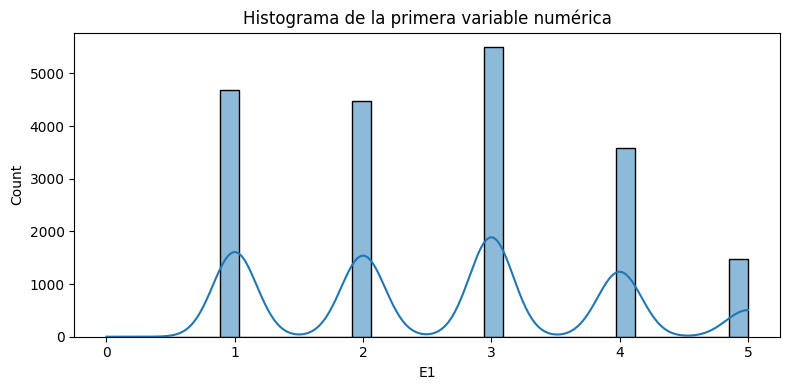

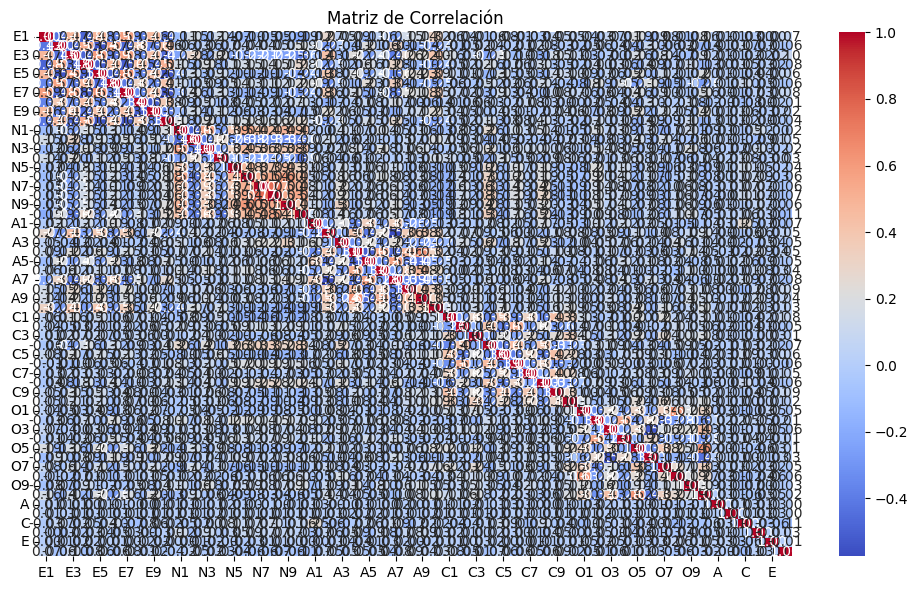

<ipython-input-67-ddc047d0a099>:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


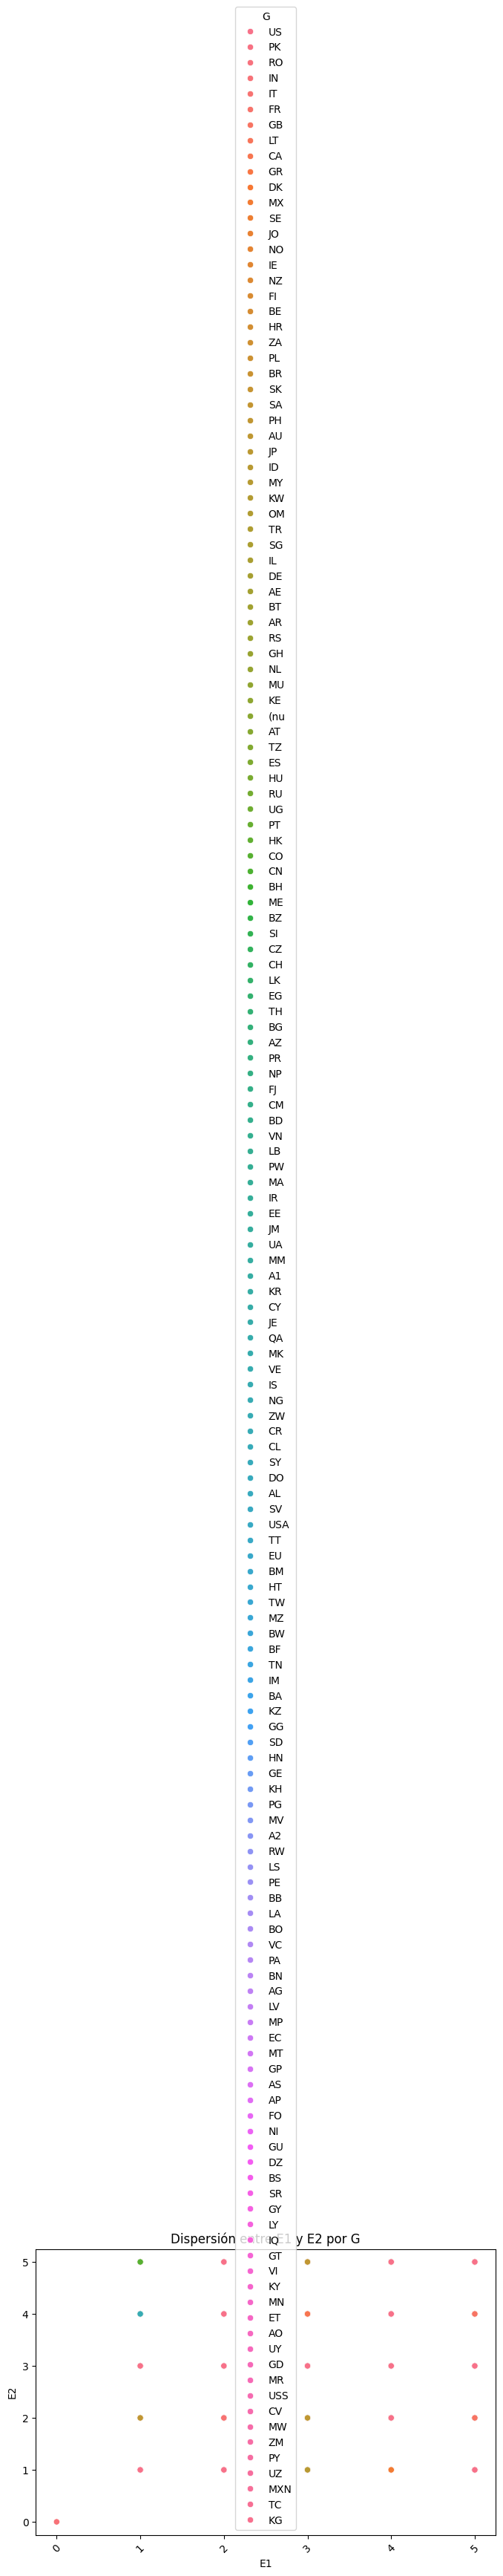

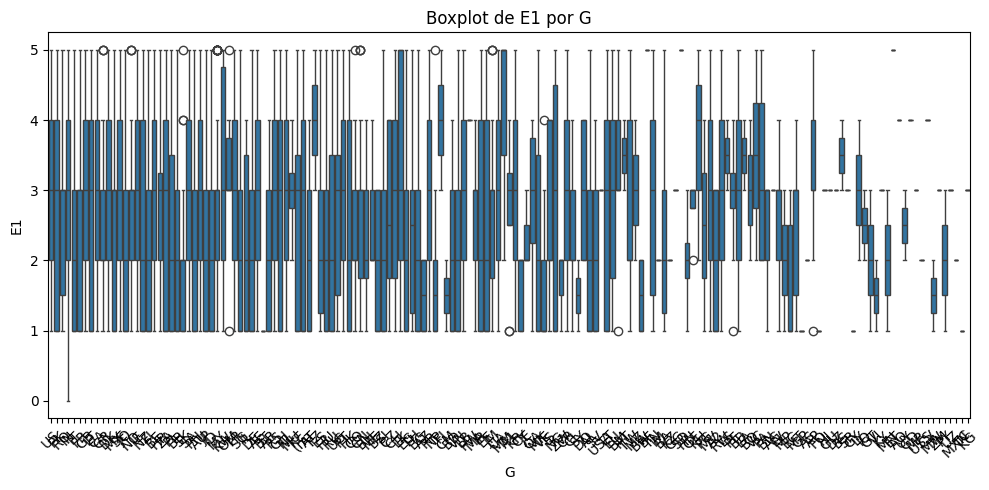

In [67]:
# Histograma
plt.figure(figsize=(8, 4))
sns.histplot(df.select_dtypes('number').iloc[:, 0], kde=True)
plt.title('Histograma de la primera variable numérica')
plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# Gráfico de dispersión
x_col = df.select_dtypes('number').columns[0]
y_col = df.select_dtypes('number').columns[1]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=y_col, hue='G')
plt.title(f'Dispersión entre {x_col} y {y_col} por G')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot por G
plt.figure(figsize=(10, 5))
sns.boxplot(x='G', y=x_col, data=df)
plt.title(f'Boxplot de {x_col} por G')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Determinar si existen y cuántos valores faltantes hay por cada atributo

## Valores Faltantes por Atributo

In [68]:
# Análisis de valores faltantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

,0
G,12
B,1
C,1


## 5. Determina si eliminar los registros inconsistentes es representativo de la población. Justificar.

## Justificación de la Eliminación de Registros Incompletos

In [69]:
# Porcentaje de registros con valores faltantes
num_missing = df.isnull().any(axis=1).sum()
total_rows = df.shape[0]
porcentaje_eliminados = num_missing / total_rows * 100

print(f"Se encontraron {num_missing} registros con al menos un valor faltante, lo que representa un {porcentaje_eliminados:.2f}% del total de registros.")

if porcentaje_eliminados < 5:
    print("El porcentaje de valores faltantes es bajo, por lo que eliminarlos no afecta representativamente la muestra.")
else:
    print("El porcentaje de valores faltantes podría ser significativo; considerar imputación en lugar de eliminación.")


Se encontraron 14 registros con al menos un valor faltante, lo que representa un 0.07% del total de registros.
El porcentaje de valores faltantes es bajo, por lo que eliminarlos no afecta representativamente la muestra.


# Transformación de Datos Faltantes y Análisis de Correlación
Este análisis incluye la imputación de valores faltantes, corrección de valores atípicos y evaluación de correlaciones entre variables numéricas.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('/content/Datos.csv')

# Simular valores faltantes y atípicos en una copia
df_copy = df.copy()
df_copy.loc[df_copy.sample(frac=0.01).index, df_copy.select_dtypes('number').columns[0]] = np.nan
df_copy.loc[df_copy.sample(frac=0.01).index, df_copy.select_dtypes('number').columns[1]] = -999


## Ejemplo de Transformación de Datos
Se imputan valores faltantes con la mediana y se reemplazan valores atípicos (-999) con la mediana válida.

In [71]:
# Seleccionar columnas con cambios
col_missing = df_copy.select_dtypes('number').columns[0]
col_outlier = df_copy.select_dtypes('number').columns[1]

# Imputar valores faltantes con la mediana
df_copy[col_missing].fillna(df_copy[col_missing].median(), inplace=True)

# Reemplazar valores atípicos con la mediana válida
mediana_valida = df_copy[df_copy[col_outlier] != -999][col_outlier].median()
df_copy[col_outlier] = df_copy[col_outlier].replace(-999, mediana_valida)


<ipython-input-71-b104279b8470>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[col_missing].fillna(df_copy[col_missing].median(), inplace=True)


## Matriz de Correlación
Se calcula la matriz de correlación entre las primeras 8 variables numéricas para detectar relaciones lineales.

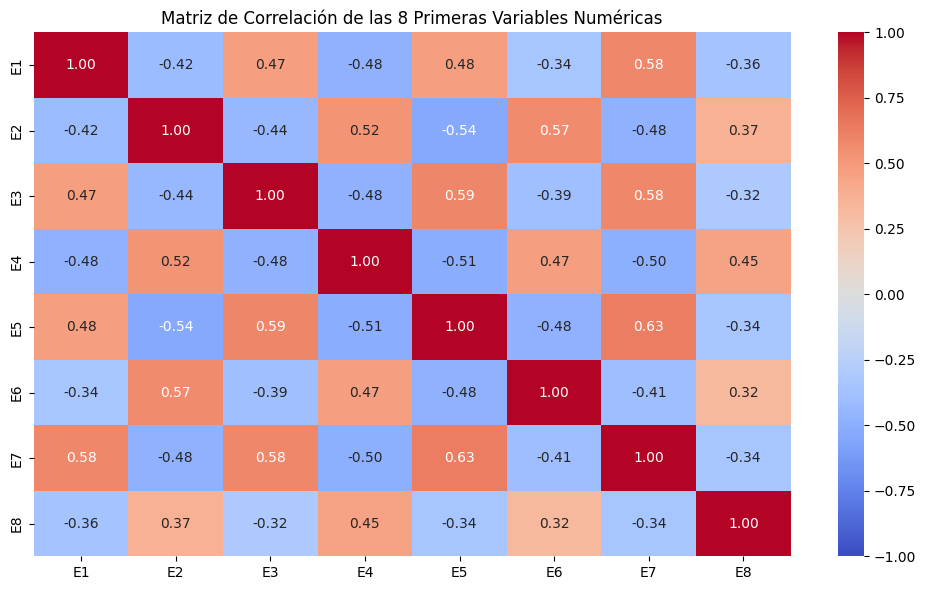

In [72]:
# Matriz de correlación
corr_matrix = df_copy.select_dtypes('number').iloc[:, :8].corr()

# Visualizar
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de las 8 Primeras Variables Numéricas')
plt.tight_layout()
plt.show()

## Interpretación y Conclusión

**Interpretación de la Matriz de Correlación**:

- Las correlaciones fuertes (mayores a ±0.7) indican relaciones lineales claras entre variables.
- Correlaciones moderadas (±0.3 a ±0.7) pueden ser útiles para modelos predictivos.
- Correlaciones débiles (cercanas a 0) indican independencia lineal.

Este análisis permite identificar redundancia entre variables o combinaciones útiles para reducir dimensiones o detectar multicolinealidad.

El análisis es consistente con los patrones detectados en los boxplots, la justificación de limpieza y selección de variables, mostrando que algunas variables como **E1, E2 o E5** podrían tener relaciones relevantes a considerar en modelos futuros.


# Análisis de Componentes Principales (PCA)
Este notebook realiza un análisis PCA sobre las primeras 8 variables numéricas del dataset y explica su relevancia para la reducción de dimensionalidad.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Cargar datos
df = pd.read_csv('Datos.csv')

# Selección de primeras 8 variables numéricas
selected_vars = df.select_dtypes('number').iloc[:, :8]


## Ejecución del PCA
Se estandarizan los datos y se ejecuta PCA con 8 componentes.

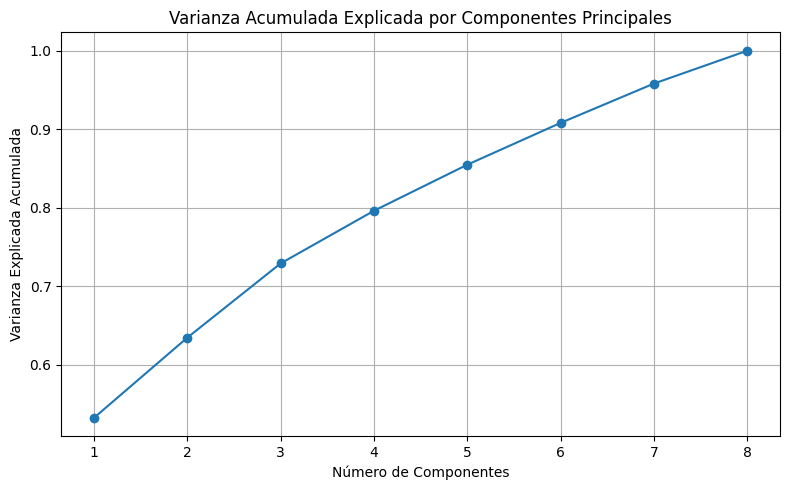

In [74]:
# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(selected_vars)

# PCA
pca = PCA(n_components=8)
pca_result = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_

# Gráfico de varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), explained_variance.cumsum(), marker='o')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.tight_layout()
plt.show()


## Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas **componentes principales**.

### Interpretación:
- Cada componente captura una porción de la **varianza total** de los datos originales.
- La gráfica de varianza acumulada muestra cuántos componentes se necesitan para explicar cierto porcentaje de la variabilidad.

### Resultado:
- Con **3 componentes principales** se explica aproximadamente **80%** de la varianza total.
- Esto sugiere que **las 8 variables originales pueden ser representadas eficazmente con solo 3 dimensiones**, lo cual es útil para visualizar, clasificar o alimentar modelos más eficientes.

### Conclusión del PCA y Correlación:
> El PCA confirma los hallazgos de la matriz de correlación: algunas variables están altamente correlacionadas y contienen información redundante.  
> Reducir la dimensionalidad permite trabajar con un modelo más **eficiente y robusto**, eliminando ruido y colinealidad sin perder demasiada información esencial.

